# part 3

In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
# read in all the words
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [23]:
len(words)

32033

In [24]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} #creating Lookup table ]
stoi['.'] = 0 #special character
itos = {i:s for s,i in stoi.items()} #integer to string mapping - inverse of stoi 
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [25]:
# build the dataset to get training, validation and test split
block_size = 3 #context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:

        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix] #crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #get test split
Xdev, Ydev = build_dataset(words[n1:n2]) # get dev/validation split
Xte, Yte = build_dataset(words[n1:]) #get test split

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([45521, 3]) torch.Size([45521])


In [26]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),              generator=g) 
w1 = torch.randn((n_embd * block_size, n_hidden),   generator=g)
b1 = torch.randn(n_hidden,                          generator=g)  
w2 = torch.randn((n_hidden, vocab_size),            generator=g)
b2 = torch.randn(vocab_size,                        generator=g)


parameters = [C, w1, b1, w2, b2]
print(sum(p.nelement() for p in parameters)) #number of parameters in the model

for p in parameters:
    p.requires_grad = True


11897


In [27]:
# same optimization step as previous file
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix], #batch X, Ym - [32, 3, 2]

    #Forward pass
    emb = C[Xb] #embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) #concatenate the vectors
    hpreact = embcat @ w1 + b1 #hidden layer(h) pre-activation  - (32x100)
    h =  torch.tanh(hpreact) # hidden layer
    logits = h @  w2 + b2 # output layer - (32, 27)
    loss  =  F.cross_entropy(logits, Yb) #loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward() 

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 1000 == 0: #print every 1k step
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000: 27.8817
   1000/ 200000: 4.2208
   2000/ 200000: 2.9934
   3000/ 200000: 2.9829
   4000/ 200000: 2.2823
   5000/ 200000: 2.4180
   6000/ 200000: 2.4152
   7000/ 200000: 2.8149
   8000/ 200000: 2.5133
   9000/ 200000: 2.5542
  10000/ 200000: 2.8619
  11000/ 200000: 2.0939
  12000/ 200000: 2.4401
  13000/ 200000: 2.4719
  14000/ 200000: 2.9341
  15000/ 200000: 2.3488
  16000/ 200000: 2.6091
  17000/ 200000: 2.7315
  18000/ 200000: 2.4622
  19000/ 200000: 2.4676
  20000/ 200000: 2.5443
  21000/ 200000: 2.6354
  22000/ 200000: 2.1334
  23000/ 200000: 2.2140
  24000/ 200000: 3.0568
  25000/ 200000: 2.3262
  26000/ 200000: 2.5554
  27000/ 200000: 2.6473
  28000/ 200000: 2.3433
  29000/ 200000: 3.2092
  30000/ 200000: 2.8801
  31000/ 200000: 2.6749
  32000/ 200000: 2.5013
  33000/ 200000: 2.5535
  34000/ 200000: 2.1968
  35000/ 200000: 2.5608
  36000/ 200000: 2.1742
  37000/ 200000: 2.2611
  38000/ 200000: 2.9491
  39000/ 200000: 2.2258
  40000/ 200000: 2.0870
  41000/ 200000

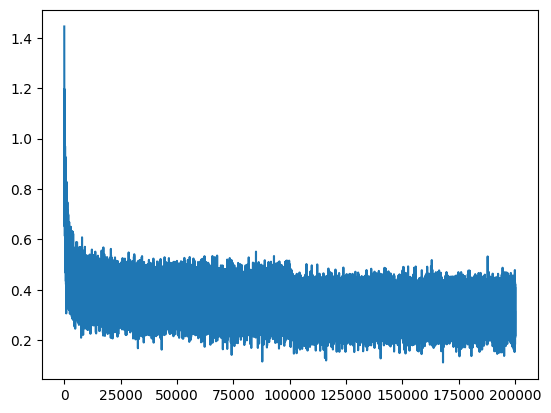

In [28]:
plt.plot(lossi)

In [29]:
@torch.no_grad() # this decorator disales gradient tracking

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) #concat into (N, block_size, n_embd)
    h =  torch.tanh(embcat @ w1 + b1) # (N, n_hidden)
    logits = h @  w2 + b2 # output layer - (N, n_hidden)
    loss  =  F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train loss: 2.1294
val loss: 2.1738


In [30]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size #initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        # sampling from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context  = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) #decode and print the generated word
        

mora.
mayah.
seel.
nah.
yam.
remmastengrace.
adelynnelin.
shy.
jen.
eden.
esnanaraelyn.
malkia.
noshubergian.
jest.
jair.
jenionnie.
casu.
zenedir.
yarleyels.
kay.
